In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
uploaded = files.upload()

Saving auto-mpg.data to auto-mpg.data


In [48]:
sns.set(style="whitegrid", palette="muted", font_scale=1.1)
df = pd.read_csv('auto-mpg.data')
print(df)


    18.0   8   307.0      130.0      3504.      12.0   70  1\t"chevrolet chevelle malibu"
0    15.0   8   350.0      165.0      3693.      11...                                   
1    18.0   8   318.0      150.0      3436.      11...                                   
2    16.0   8   304.0      150.0      3433.      12...                                   
3    17.0   8   302.0      140.0      3449.      10...                                   
4    15.0   8   429.0      198.0      4341.      10...                                   
..                                                 ...                                   
392  27.0   4   140.0      86.00      2790.      15...                                   
393  44.0   4   97.00      52.00      2130.      24...                                   
394  32.0   4   135.0      84.00      2295.      11...                                   
395  28.0   4   120.0      79.00      2625.      18...                                   
396  31.0 

In [60]:
col_names = ['mpg', 'cylinders', 'displacement', 'horsepower',
             'weight', 'acceleration', 'model_year', 'origin', 'car_name']
df = pd.read_csv(
    'auto-mpg.data',
    sep=r'\s+',
    names=col_names
)
print(df.head())

    mpg  cylinders  displacement horsepower  weight  acceleration  model_year  \
0  18.0          8         307.0      130.0  3504.0          12.0          70   
1  15.0          8         350.0      165.0  3693.0          11.5          70   
2  18.0          8         318.0      150.0  3436.0          11.0          70   
3  16.0          8         304.0      150.0  3433.0          12.0          70   
4  17.0          8         302.0      140.0  3449.0          10.5          70   

   origin                   car_name  
0       1  chevrolet chevelle malibu  
1       1          buick skylark 320  
2       1         plymouth satellite  
3       1              amc rebel sst  
4       1                ford torino  


upload and read data. sns.set() applies Seaborn's default theme to all plots. set column names and print first 5 rows.

In [61]:
print(df.describe())

              mpg   cylinders  displacement       weight  acceleration  \
count  398.000000  398.000000    398.000000   398.000000    398.000000   
mean    23.514573    5.454774    193.425879  2970.424623     15.568090   
std      7.815984    1.701004    104.269838   846.841774      2.757689   
min      9.000000    3.000000     68.000000  1613.000000      8.000000   
25%     17.500000    4.000000    104.250000  2223.750000     13.825000   
50%     23.000000    4.000000    148.500000  2803.500000     15.500000   
75%     29.000000    8.000000    262.000000  3608.000000     17.175000   
max     46.600000    8.000000    455.000000  5140.000000     24.800000   

       model_year      origin  
count  398.000000  398.000000  
mean    76.010050    1.572864  
std      3.697627    0.802055  
min     70.000000    1.000000  
25%     73.000000    1.000000  
50%     76.000000    1.000000  
75%     79.000000    2.000000  
max     82.000000    3.000000  


review data. df.describe() shows statistical summary of all numeric columns

In [62]:
df.columns = ['mpg', 'cylinders', 'displacement', 'horsepower',
              'weight', 'acceleration', 'model_year', 'origin', 'car_name']
print(df.columns.tolist())
print(df.head())

['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin', 'car_name']
    mpg  cylinders  displacement horsepower  weight  acceleration  model_year  \
0  18.0          8         307.0      130.0  3504.0          12.0          70   
1  15.0          8         350.0      165.0  3693.0          11.5          70   
2  18.0          8         318.0      150.0  3436.0          11.0          70   
3  16.0          8         304.0      150.0  3433.0          12.0          70   
4  17.0          8         302.0      140.0  3449.0          10.5          70   

   origin                   car_name  
0       1  chevrolet chevelle malibu  
1       1          buick skylark 320  
2       1         plymouth satellite  
3       1              amc rebel sst  
4       1                ford torino  


use column names in auto-mpg.names. print in list format.

In [63]:
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

print(f"\n── Missing horsepower values: {df['horsepower'].isna().sum()}")
print(df[df['horsepower'].isna()][['car_name', 'horsepower']])



── Missing horsepower values: 6
                 car_name  horsepower
32             ford pinto         NaN
126         ford maverick         NaN
330  renault lecar deluxe         NaN
336    ford mustang cobra         NaN
354           renault 18i         NaN
374        amc concord dl         NaN


identify missing horsepower data by converting the horsepower column from text to numeric values, replacing any '?' with NaN. count how many are missing (6) and list them.

In [64]:
df['origin'] = df['origin'].map({1: 'USA', 2: 'Asia', 3: 'Europe'})
print(df['origin'].value_counts())

origin
USA       249
Europe     79
Asia       70
Name: count, dtype: int64


convert origin values to USA, EU, and Asia. Use map() to associate columns 1,2,3 to regions respectively. use value_counts() to count how many cars belong to each region

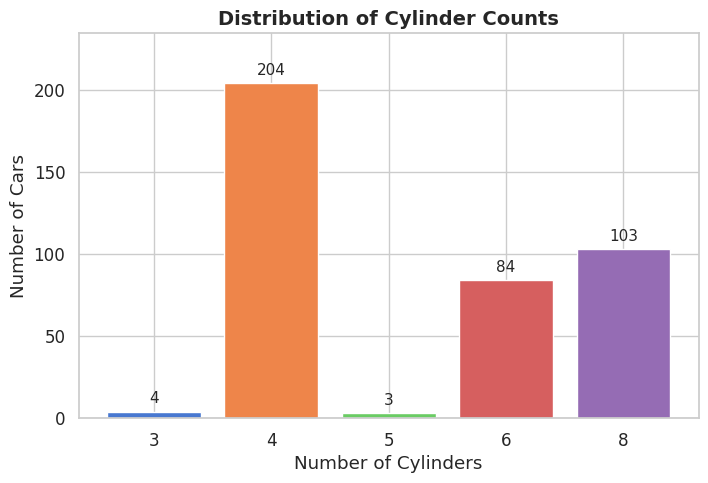

In [67]:
fig, ax = plt.subplots(figsize=(8, 5))
cyl_counts = df['cylinders'].value_counts().sort_index()
bars = ax.bar(
    cyl_counts.index.astype(str),
    cyl_counts.values,
    color=sns.color_palette("muted", len(cyl_counts))
)
ax.bar_label(bars, padding=4, fontsize=11)
ax.set_title('Distribution of Cylinder Counts', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Cylinders')
ax.set_ylabel('Number of Cars')
ax.set_ylim(0, cyl_counts.max() * 1.15)
plt.savefig('plot1_cylinders_bar.png', dpi=150)
plt.show()


count how many cars have each cylinder type and draw a bar chart. use figsize() to create blank canvas for chart. use value_counts().sort_index() to
count how many cars have x cylinders,then sort. create the bars and labels. show number of cars on top of each bar.

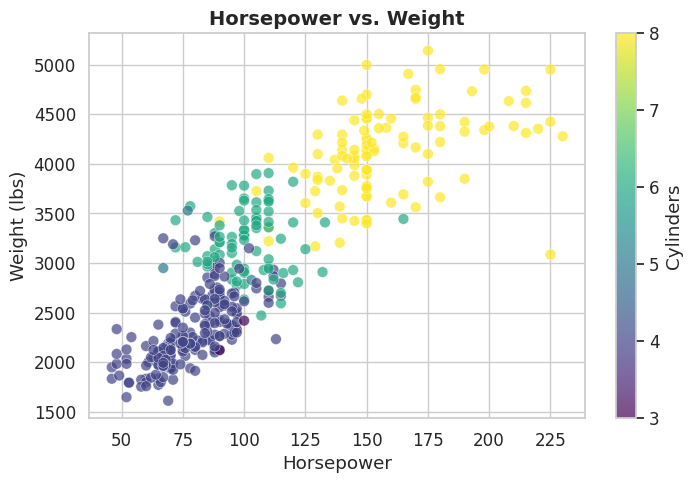

In [70]:
fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(
    df['horsepower'], df['weight'],
    c=df['cylinders'], cmap='viridis',
    alpha=0.7, edgecolors='white', linewidths=0.4, s=60
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Cylinders')
ax.set_title('Horsepower vs. Weight', fontsize=14, fontweight='bold')
ax.set_xlabel('Horsepower')
ax.set_ylabel('Weight (lbs)')

plt.savefig('plot2_hp_vs_weight.png', dpi=150)
plt.show()

plot every car as a dot showing the horsepower and weight, with dot color showing how many cylinders it has. Use scatter() to draw a dot for every car on the chart, positioned by its horsepower and weight, colored by its cylinder count. set labels.

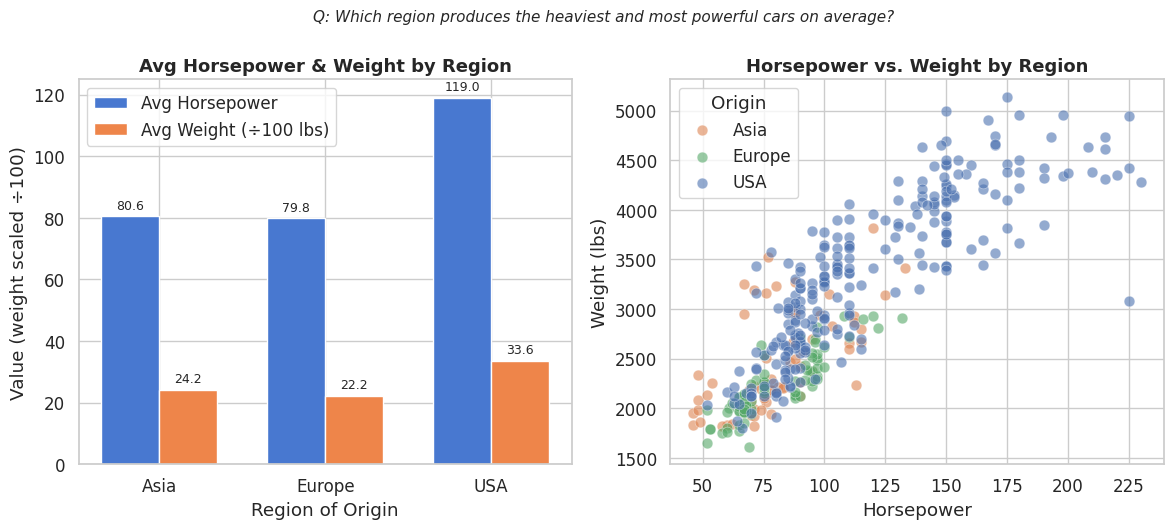

In [72]:
# QUESTION: Which region produces the heaviest and most powerful cars on average?
#
# ANSWER: USA consistently produces the heaviest and most powerful cars,
# while Asian and European manufacturers favor lighter, lower-horsepower builds.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

summary = df.groupby('origin')[['horsepower', 'weight']].mean().reset_index()

x = np.arange(len(summary['origin']))
width = 0.35

bars1 = axes[0].bar(x - width/2, summary['horsepower'], width,
                    label='Avg Horsepower', color=sns.color_palette("muted")[0])
bars2 = axes[0].bar(x + width/2, summary['weight'] / 100, width,
                    label='Avg Weight (÷100 lbs)', color=sns.color_palette("muted")[1])

axes[0].bar_label(bars1, fmt='%.1f', padding=3, fontsize=9)
axes[0].bar_label(bars2, fmt='%.1f', padding=3, fontsize=9)
axes[0].set_xticks(x)
axes[0].set_xticklabels(summary['origin'])
axes[0].set_title('Avg Horsepower & Weight by Region', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Region of Origin')
axes[0].set_ylabel('Value (weight scaled ÷100)')
axes[0].legend()

origin_colors = {'USA': '#4c72b0', 'Asia': '#dd8452', 'Europe': '#55a868'}
for region, grp in df.groupby('origin'):
    axes[1].scatter(grp['horsepower'], grp['weight'],
                    label=region, alpha=0.6, s=60,
                    color=origin_colors[region],
                    edgecolors='white', linewidths=0.4)

axes[1].set_title('Horsepower vs. Weight by Region', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Horsepower')
axes[1].set_ylabel('Weight (lbs)')
axes[1].legend(title='Origin')

plt.suptitle(
    'Q: Which region produces the heaviest and most powerful cars on average?',
    fontsize=11, style='italic', y=1.02
)

plt.savefig('plot3_power_weight_by_origin.png', dpi=150, bbox_inches='tight')
plt.show()

Group all cars by region and calculate the average horsepower and weight for each region. Create evenly spaced positions on the x-axis. Draw the average horsepower bar for each region. Draw the average weight bar for each region. Add the exact number on top of each bar. Add labels and colors. Loop through each region and draw its cars as dots on the scatterplot, each region in its own color. Display question as title.